In [ ]:
import json
import re
import srsly
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from rank_bm25 import BM25Okapi
from beir.retrieval.evaluation import EvaluateRetrieval
from openai import OpenAI
from pydantic import BaseModel, Field

In [ ]:
# =========================
# PATHS
# =========================

QUESTIONS_FILE = Path("../QandA_100.jsonl")

PATIENT_QUERIES_FILE = Path("../Task4_Cancer_Patients/Updated_PAR_cancer/new_PAR_queries/new_cancer_train_queries.jsonl")
ARTICLE_CORPUS_FILE = Path("../Task4_Cancer_Patients/Updated_PAR_cancer/new_cancer_corpus.jsonl")

TOP_K = 5
K_LIST = [1, 3, 5]

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_DIR = OUTPUT_DIR / "combined"
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_RETRIEVAL = OUTPUT_DIR / f"bm25_PAR_retrieval_results_top{TOP_K}.jsonl"

OUTPUT_FULL = COMBINED_DIR / f"hipporag_results_full_combined.jsonl"
OUTPUT_SHORT = COMBINED_DIR / f"hipporag_results_short_combined.jsonl"
OUTPUT_TXT = COMBINED_DIR / f"hipporag_results_combined.txt"
OUTPUT_CSV = COMBINED_DIR / f"hipporag_results_combined.csv"

In [18]:
# ============================
# Prepare benchmark questions
# ============================

# Load and basic cleaning
questions = pd.DataFrame(list(srsly.read_jsonl(QUESTIONS_FILE)))
for col in ["patient_id", "article_id"]:
    questions[col] = questions[col].astype(str)

# Filter invalid questions
questions = questions[
    questions["question"].notna()
    & (questions["question"].astype(str).str.strip() != "")
    & (~questions["question"].astype(str).str.contains("error", case=False, na=False))
].copy()

# Vectorized ID generation
questions["question_id"] = [f"q_{i:04d}" for i in range(len(questions))]

print(f"Usable questions: {questions.shape}")

Usable questions: (106, 7)


In [19]:
# =========================
# Prepare lookup mappings
# =========================

def process_corpus(path, include_title=True):
    df = pd.DataFrame(list(srsly.read_jsonl(path)))
    df["_id"] = df["_id"].astype(str)
    df["text"] = df["text"].fillna("")
    
    if include_title:
        df["title"] = df.get("title", "").fillna("")
        df["retrieval_text"] = df["title"] + " " + df["text"]
    else:
        df["retrieval_text"] = df["text"]
    
    return df

# Process articles
articles = process_corpus(ARTICLE_CORPUS_FILE, include_title=True)
article_id_to_text = articles.set_index("_id")["retrieval_text"].to_dict()
article_id_to_title = articles.set_index("_id")["title"].to_dict()
article_ids = articles["_id"].tolist()

# Process patients
patients = process_corpus(PATIENT_QUERIES_FILE, include_title=False)
patient_id_to_text = patients.set_index("_id")["retrieval_text"].to_dict()
patient_ids = patients["_id"].tolist()

print(f"Articles: {articles.shape} | Patients: {patients.shape}")

Articles: (398228, 4) | Patients: (54810, 3)


In [20]:
def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return text.split()

In [21]:
# =========================
# BM25 Indexing
# =========================

# Tokenize corpus text
articles["tokenized"] = articles["retrieval_text"].apply(tokenize)
patients["tokenized"] = patients["retrieval_text"].apply(tokenize)


# Initialize BM25 indexes using the tokenized document lists
article_bm25 = BM25Okapi(articles["tokenized"].tolist())
patient_bm25 = BM25Okapi(patients["tokenized"].tolist())

In [22]:
def bm25_retrieve(query, bm25_index, doc_ids, top_k=5):
    tokenized_query = tokenize(query)
    scores = bm25_index.get_scores(tokenized_query)

    top_indices = scores.argsort()[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            "rank": rank,
            "id": doc_ids[idx],
            "score": float(scores[idx])
        })

    return results

In [ ]:
# ========================================
# BM25 Retrieval & Context Enrichment
# ========================================

retrieval_results = []

for _, row in questions.iterrows():
    question_id = row["question_id"]
    question = row["question"]

    retrieved_articles = bm25_retrieve(
        query=question,
        bm25_index=article_bm25,
        doc_ids=article_ids,
        top_k=TOP_K
    )

    retrieved_patients = bm25_retrieve(
        query=question,
        bm25_index=patient_bm25,
        doc_ids=patient_ids,
        top_k=TOP_K
    )

    article_contexts = []
    for r in retrieved_articles:
        aid = r["id"]
        article_contexts.append({
            "rank": r["rank"],
            "article_id": aid,
            "score": r["score"],
            "title": article_id_to_title.get(aid, ""),
            "text": article_id_to_text.get(aid, "")
        })
            
    patient_contexts = []
    for r in retrieved_patients:
        pid = r["id"]
        patient_contexts.append({
            "rank": r["rank"],
            "patient_id": pid,
            "score": r["score"],
            "text": patient_id_to_text.get(pid, "")
        })

    retrieval_results.append({
        "question_id": question_id,
        "question": question,
        "gold_article_id": row["article_id"],
        "gold_patient_id": row["patient_id"],
        "gold_short": row.get("short_answer", ""),
        "gold_long": row.get("long_answer", ""),
        "retrieved_articles": article_contexts,
        "retrieved_patients": patient_contexts
    })

# Save retrieval results to JSONL
srsly.write_jsonl(OUTPUT_RETRIEVAL, retrieval_results)
print("Saved:", OUTPUT_RETRIEVAL)

Saved: bm25_PAR_retrieval_results_top5.jsonl


In [38]:
def evaluate_retrieval(results, gold_key, retrieved_key, label, k_values):
    qrels = {
        str(res["question_id"]): {res[gold_key]: 1} 
        for res in results
    }
    
    run = {}
    for res in results:
        qid = str(res["question_id"])
        scores_dict = {}
        
        for doc in res[retrieved_key]:
            doc_id = str(doc.get("article_id") or doc.get("patient_id"))
            scores_dict[doc_id] = float(doc["score"])
            
        run[qid] = scores_dict

    ndcg, _map, recall, precision = EvaluateRetrieval.evaluate(qrels, run, k_values)
    
    # Output
    print(f"--- {label} ---")
    print(f"{'k':<4} | {'nDCG':<10} | {'Recall':<10} | {'Precision':<10}")
    print("-" * 45)

    for k in k_values:
        print(f"k={k:<2} | {ndcg[f'NDCG@{k}']:<10.4f} | {recall[f'Recall@{k}']:<10.4f} | {precision[f'P@{k}']:<10.4f}")
    print()


    return ndcg, recall, precision

In [39]:
def plot_retrieval_performance(ndcg_scores, recall_scores, precision_scores, label, k_values):
    k_labels = [str(k) for k in k_values]
    n_vals = [ndcg_scores[f"NDCG@{k}"] for k in k_values]
    r_vals = [recall_scores[f"Recall@{k}"] for k in k_values]
    p_vals = [precision_scores[f"P@{k}"] for k in k_values]

    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    
    plt.plot(k_labels, n_vals, marker='o', label='nDCG', linewidth=2)
    plt.plot(k_labels, r_vals, marker='s', label='Recall', linewidth=2)
    plt.plot(k_labels, p_vals, marker='^', label='Precision', linewidth=2, linestyle='--')

    plt.title(f"Retrieval Performance: {label}", fontsize=14, pad=15)
    plt.xlabel("Top-K", fontsize=12)
    plt.ylabel("Score", fontsize=12)
    plt.ylim(0, 1.05)
    plt.legend(frameon=True)
    
    for i, val in enumerate(n_vals):
        plt.text(i, val + 0.02, f"{val:.2f}", ha='center', fontsize=9)
    for i, val in enumerate(r_vals):
        plt.text(i, val + 0.02, f"{val:.2f}", ha='center', fontsize=9)
    for i, val in enumerate(p_vals):
        plt.text(i, val + 0.02, f"{val:.2f}", ha='center', fontsize=9)

    sns.despine()
    plt.tight_layout()
    plt.show()

--- ARTICLES ---
k    | nDCG       | Recall     | Precision 
---------------------------------------------
k=1  | 0.0943     | 0.0943     | 0.0943    
k=3  | 0.1370     | 0.1698     | 0.0566    
k=5  | 0.1529     | 0.2076     | 0.0415    
k=10 | 0.1691     | 0.2547     | 0.0255    



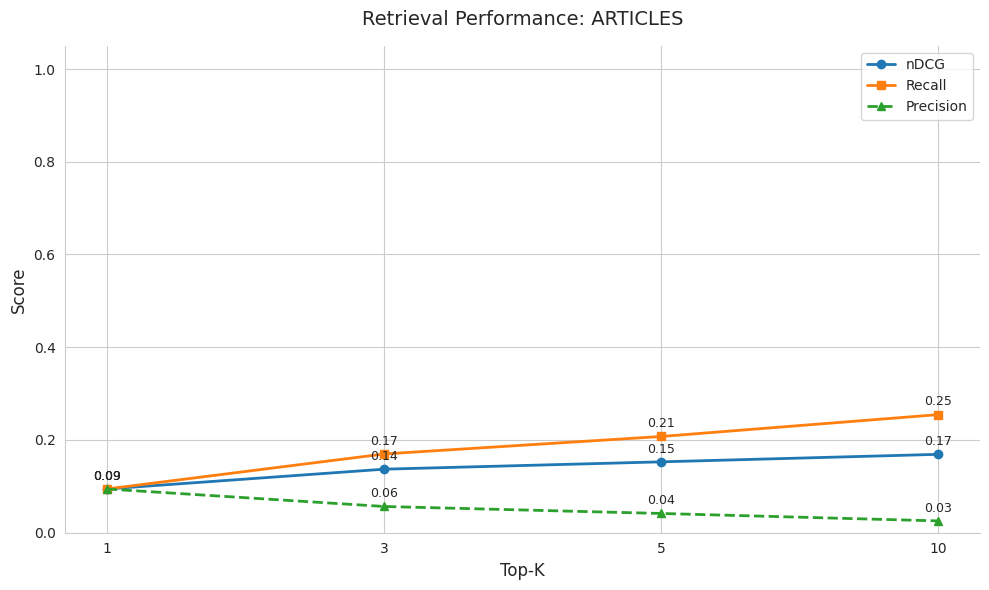

--- PATIENTS ---
k    | nDCG       | Recall     | Precision 
---------------------------------------------
k=1  | 0.5849     | 0.5849     | 0.5849    
k=3  | 0.6586     | 0.7076     | 0.2359    
k=5  | 0.6813     | 0.7641     | 0.1528    
k=10 | 0.7055     | 0.8396     | 0.0840    



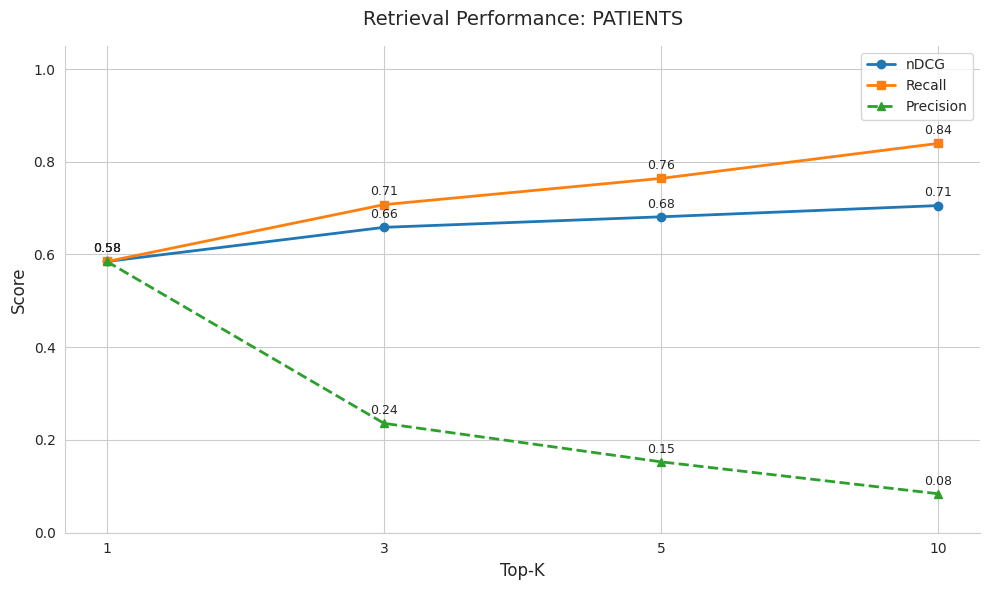

In [49]:
# ===============================
# Evaluate Retrieval Performance
# ===============================

ndcg_art, recall_art, prec_art = evaluate_retrieval(retrieval_results, "gold_article_id", "retrieved_articles", "ARTICLES", K_LIST)
plot_retrieval_performance(ndcg_art, recall_art, prec_art, "ARTICLES", K_LIST)

ndcg_pat, recall_pat, prec_pat = evaluate_retrieval(retrieval_results, "gold_patient_id", "retrieved_patients", "PATIENTS", K_LIST)
plot_retrieval_performance(ndcg_pat, recall_pat, prec_pat, "PATIENTS", K_LIST)

In [3]:
def normalize(results):
        if not results:
            return []
        scores = [r['score'] for r in results]
        max_s = max(scores)
        min_s = min(scores)
        if max_s == min_s:
            return [{**r, 'norm_score': 1.0} for r in results]
        return [
            {**r, 'norm_score': (r['score'] - min_s) / (max_s - min_s)}
            for r in results
        ]

def get_combined_top_k(articles, patients, total_k=TOP_K, alpha=0.7):
    norm_articles = normalize(articles)
    norm_patients = normalize(patients)

    for a in norm_articles:
        a['source_type'] = 'article'
        a['final_score'] = alpha * a['norm_score']

    for p in norm_patients:
        p['source_type'] = 'patient'
        p['final_score'] = (1 - alpha) * p['norm_score']

    combined = norm_articles + norm_patients
    combined_sorted = sorted(combined, key=lambda x: x['final_score'], reverse=True)

    return combined_sorted[:total_k]

In [4]:
### prepare LLM
BASE_URL = "https://llm3-compute.cms.hu-berlin.de/v1/"
OPENAI_API_KEY = "secret_but_not_used"

client = OpenAI(base_url=BASE_URL, api_key=OPENAI_API_KEY)

### specify output format
class QuestionResponse(BaseModel):
    question: str
    short_answer: str = Field(..., description="one specific medical entity") 
    long_answer: str = Field(..., description="Explain why this entity is the correct answer based on the combination of clinical details from the case reports and biomedical knowledge from the abstracts.") 

In [5]:
def build_rag_prompt(question, combined_docs):
    context_parts = []
    
    for doc in combined_docs:
        if doc['source_type'] == 'article':
            part = (f"--- RESEARCH ARTICLE: {doc.get('title', 'No Title')} ---\n"
                    f"ID: {doc.get('article_id')}\n"
                    f"Content: {doc.get('text')}")
        else:
            part = (f"--- PATIENT RECORD ---\n"
                    f"ID: {doc.get('patient_id')}\n"
                    f"Content: {doc.get('text')}")
        context_parts.append(part)

    all_context = "\n\n".join(context_parts)

    prompt = f"""You are a medical expert assistant. Your task is to answer the question based EXCLUSIVELY on the provided context (Patient Records and Research Articles).

        ### PROVIDED CONTEXT:
        {all_context}

        ### QUESTION:
        {question}

        ### INSTRUCTIONS:
        1. Use only the information provided above. 
        2. If the answer is not contained within the context, state that there is insufficient information.
        3. Maintain a professional, clinical tone.
        4. Mention which patient record or article your information comes from if possible.
        5. The short answer should be a concrete medical entity such as:
            - a drug
            - a diagnostic test
            - a biomarker
            - a mutation
            - a procedure
            - a specific treatment strategy with a clear name
        """
    
    return prompt

In [6]:
def generate_answer(question, retrieved_docs):
    prompt = build_rag_prompt(
        question, 
        retrieved_docs
    )

    response = client.beta.chat.completions.parse(
        model="llm3",
        messages=[
            {"role": "system", "content": "You are a medical expert assistant that provides structured responses based on clinical evidence."},
            {"role": "user", "content": prompt}
        ],
        response_format=QuestionResponse,
        temperature=0
    )

    return response.choices[0].message.parsed

In [ ]:
# ===============================
# Let LLM generate answers
# ===============================
all_results = []

with open(OUTPUT_RETRIEVAL, 'r', encoding='utf-8') as f_in, \
     open(OUTPUT_FULL, 'w', encoding='utf-8') as f_out_full, \
     open(OUTPUT_SHORT, 'w', encoding='utf-8') as f_out_short, \
     open(OUTPUT_TXT, 'w', encoding='utf-8') as f_out_txt:
     
    lines = f_in.readlines()

    for line in lines:
        data = json.loads(line)

        docs_top_k = get_combined_top_k(data["retrieved_articles"], data["retrieved_patients"], total_k=TOP_K)

        try:
            question_id = data.get('question_id')
            
            model_output = generate_answer(
                data["question"],
                docs_top_k
            )

            full_result = {
                "question_id": data.get("question_id"),
                "question": data["question"],
                "model_short": model_output.short_answer,
                "model_long": model_output.long_answer,
                "gold_short": data.get("gold_short", "N/A"),
                "gold_long": data.get("gold_long", "N/A")
            }

            short_result = {
                "question": data["question"],
                "model_short": model_output.short_answer,
                "gold_short": data.get("gold_short", "N/A")
            }

            all_results.append(short_result)

        except Exception as e:
            print(f"Error for question {data.get('question_id')}: {e}")
            # skip to next line
            continue
        
        f_out_full.write(json.dumps(full_result, ensure_ascii=False) + '\n')
        f_out_short.write(json.dumps(short_result, ensure_ascii=False) + '\n')
            
        # TXT format
        f_out_txt.write(f"{'-'*40} QUESTION ID: {question_id} {'-'*40}\n")
        f_out_txt.write(f"Patient ID: {data.get('gold_patient_id')}\n")
        f_out_txt.write(f"Question:\n{data['question']}\n\n")
        f_out_txt.write(f"Model Short Answer: {model_output.short_answer}\n")
        f_out_txt.write(f"Gold Short Answer: {data.get('gold_short', 'N/A')}\n\n")
        f_out_txt.write(f"Model Long Answer:\n{model_output.long_answer}\n\n")
        f_out_txt.write(f"Gold Long Answer: {data.get('gold_long', 'N/A')}\n\n")
        
        f_out_full.flush()
        f_out_short.flush()
        f_out_txt.flush()

df_results = pd.DataFrame(all_results)
df_results.to_csv(OUTPUT_CSV, index=False)

In [10]:
def evaluate_answer(question, gold, model):
    if str(gold).strip().lower() == str(model).strip().lower():
        return True 
    
    prompt = f"""As a medical evaluation expert, compare the Model Answer against the Gold Answer.

    Criteria:
    1. The Model Answer is CORRECT if it identifies the same primary medical entity (drug, test, procedure, etc.) as the Gold Answer.
    2. If the Model Answer is more specific or contains additional correct information (like "Test X and Test Y" when Gold is just "Test X"), it should still be marked as CORRECT.
    3. If the Model Answer provides a different or contradictory entity, it is INCORRECT.

    Question: {question}
    Gold Answer: {gold}
    Model Answer: {model}

    Respond with ONLY a JSON object: {{"is_correct": true}} or {{"is_correct": false}}"""

    try:
        response = client.chat.completions.create(
            model="llm3",
            messages=[{"role": "user", "content": prompt}],
            response_format={ "type": "json_object" }
        )
        result = json.loads(response.choices[0].message.content)
        return result.get("is_correct", False)
    except Exception as e:
        print(f"Error judging: {e}")
        return False

In [ ]:
# ===============================
# Use LLM as judge for answers
# ===============================
df = pd.read_csv(OUTPUT_CSV)

df['is_correct'] = df.apply(
    lambda x: evaluate_answer(x['question'], x['gold_short'], x['model_short']), 
    axis=1
)

df.to_csv(OUTPUT_CSV, index=False)

accuracy = df['is_correct'].mean() * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 57.55%
